In [1]:
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import dask.array as da
import dask.dataframe as dd
import xarray as xr
from xnemogcm import open_domain_cfg, get_metrics
import xgcm
import cartopy.crs as ccrs
import cmocean
import numpy as np
from scipy.stats import linregress
import datetime
import pandas as pd

# Add SouthernDemons library to PATH
sys.path.append(os.path.abspath("../lib/"))
from teos_ten import teos_sigma0
import datesandtime

imindom = 1
imaxdom = 1440
jmindom = 1
jmaxdom = 400
kmindom = 1
kmaxdom = 75



In [2]:
df_ini.dtypes
# dtype={0: 'int64',   #Ntraj
#        1: 'float64', #x
#        2: 'float64', #y
#        3:'float64',  #z
#        4:'float64',  #subvol
#        5:'float64',  #time
#        6:'int64',    #boxface
#        7: 'float64', #temperature
#        8:'float64',  #salinity
#        9:'float64',  #density
#        10:'float64'} #density10

NameError: name 'df_ini' is not defined

In [3]:
# Define column names
column_names = [
    "Ntraj", "x", "y", "z", "subvol", "time", "boxface",
    "temperature", "salinity", "density", "density10"
]

# Define data types
dtypes = {
    0: 'int64',    # Ntraj
    1: 'float64',  # x
    2: 'float64',  # y
    3: 'float64',  # z
    4: 'float64',  # subvol
    5: 'float64',  # time
    6: 'int64',    # boxface
    7: 'float64',  # temperature
    8: 'float64',  # salinity
    9: 'float64',  # density
    10: 'float64'  # density10
}



In [4]:
direc = '/gws/nopw/j04/bas_pog/astyles/ORCA025_bwd/out_seed_chunk_imin0118_imax0120_jmin0001_jmax0398/TRACMASS_ORCA025_seed_chunk_imin0118_imax0120_jmin0001_jmax0398_ini.csv'

df_ini = dd.read_csv(direc, header=None, names=column_names, dtype=dtypes)

FileNotFoundError: An error occurred while calling the read_csv method registered to the pandas backend.
Original Message: [Errno 2] No such file or directory: '/gws/nopw/j04/bas_pog/astyles/ORCA025_bwd/out_seed_chunk_imin0118_imax0120_jmin0001_jmax0398/TRACMASS_ORCA025_seed_chunk_imin0118_imax0120_jmin0001_jmax0398_ini.csv'

In [15]:
df_ini.head()

,Ntraj,x,y,z,subvol,time,boxface,temperature,salinity,density,density10
0,1,119.0,155.5,8.5,2.919962e+08,0.0,2,-1.22,33.31,26.66,0.01
1,2,120.0,155.5,8.5,2.919962e+08,0.0,2,-1.30,33.32,26.67,0.01
2,3,118.0,156.5,8.5,2.943092e+08,0.0,2,-1.45,33.26,26.63,0.01
3,4,119.0,156.5,8.5,2.943092e+08,0.0,2,-1.45,33.27,26.64,0.01
4,5,120.0,156.5,8.5,2.943092e+08,0.0,2,-1.48,33.30,26.67,0.01


In [18]:
xmin, xmax = imindom, imaxdom
ymin, ymax = jmindom, jmaxdom
zmin, zmax = kmindom, kmaxdom

xbins = np.linspace(xmin-0.5, xmax+0.5, num=xmax-xmin+2)
ybins = np.linspace(ymin-0.5, ymax+0.5, num=ymax-ymin+2)
zbins = np.linspace(zmin-0.5, zmax+0.5, num=zmax-zmin+2)

xbins[0], xbins[-1] = -float("inf"), float("inf")
ybins[0], ybins[-1] = -float("inf"), float("inf")
zbins[0], zbins[-1] = -float("inf"), float("inf")

xcent = np.linspace(xmin, xmax, num=xmax-xmin+1, dtype=int)
ycent = np.linspace(ymin, ymax, num=ymax-ymin+1, dtype=int)
zcent = np.linspace(zmin, zmax, num=zmax-zmin+1, dtype=int)



print(xbins)
print(xcent)



#CORRECTED BINS

df_ini["binnedx_i"] = df_ini["x"].map_partitions(pd.cut, xbins, labels=xcent,right=False, retbins=False).astype(int)
df_ini["binnedy_i"] = df_ini["y"].map_partitions(pd.cut, ybins, labels=ycent,right=False, retbins=False).astype(int)
df_ini["bin_depth_i"] = df_ini["z"].map_partitions(pd.cut, zbins, labels=zcent, right=False,retbins=False).astype(int)

[  -inf    1.5    2.5 ... 1438.5 1439.5    inf]
[   1    2    3 ... 1438 1439 1440]


In [31]:
df = df_ini[df_ini['binnedx_i']==119]
df = df_ini[df_ini['binnedy_i']==200]
df_group = df.groupby("bin_depth_i")
vol = df_group.sum()['subvol'].compute()
vol = vol.reset_index()

In [32]:
vol

,bin_depth_i,subvol
0,13,7.023151e+08
1,14,2.400181e+09
2,15,2.716156e+09
3,16,3.060923e+09
4,17,3.407880e+09
5,18,3.764217e+09
6,19,4.129518e+09
7,20,4.506295e+09
8,21,4.899780e+09
9,22,5.317460e+09


Text(0, 0.5, 'k_index (depth)')

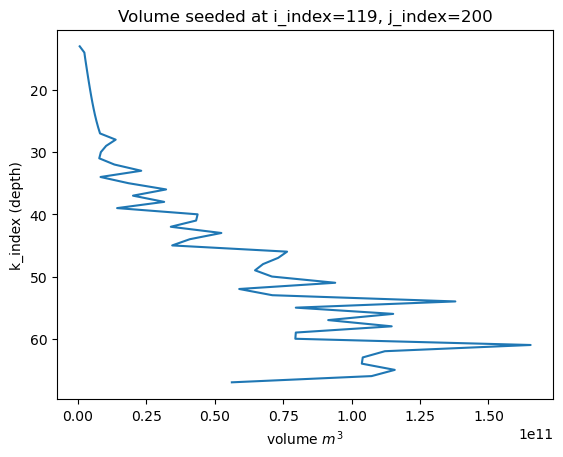

In [37]:
fig,ax = plt.subplots(1,1)
plt.plot(vol.subvol,vol.bin_depth_i)
ax.invert_yaxis()

plt.title('Volume seeded at i_index=119, j_index=200')
plt.xlabel('volume $m^3$')
plt.ylabel('k_index (depth)')